In [1]:
# =================================================
# CELL 1 — IMPORT LIBRARY
# =================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#setting tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("Library berhasil diimport!")

Library berhasil diimport!


In [8]:
# ================================================
# CELL 2 — LOAD DATASET
# ================================================

df = pd.read_csv('../data/raw/Finance_Trends.csv')

print("✅ Dataset berhasil dimuat!")
print(f"\n📊 Shape dataset: {df.shape}")
print(f"   → {df.shape[0]} baris (responden)")
print(f"   → {df.shape[1]} kolom (fitur)")

✅ Dataset berhasil dimuat!

📊 Shape dataset: (12000, 24)
   → 12000 baris (responden)
   → 24 kolom (fitur)


In [14]:
# ================================================
# CELL 3 — INSPECT AWAL
# ================================================

print("=" * 50)
print("5 DATA PERTAMA:")
print("=" * 50)
display(df.head())

print("\n" + "=" * 50)
print("NAMA KOLOM:")
print("=" * 50)

for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print("\n" + "=" * 50)
print("TIPE DATA TIAP KOLOM:")
print("=" * 50)
print(df.dtypes)

5 DATA PERTAMA:


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,Stock_Marktet,Factor,Objective,Purpose,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Male,29,Yes,2,4,7,5,3,1,6,Yes,Risk,Growth,Wealth Creation,Less than 1 year,Weekly,20%-30%,Public Provident Fund,Health Care,Dividend,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines
1,Male,28,Yes,2,3,6,5,1,4,7,Yes,Returns,Capital Appreciation,Wealth Creation,Less than 1 year,Weekly,30%-40%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Television
2,Female,28,Yes,2,3,7,5,4,1,6,Yes,Returns,Capital Appreciation,Wealth Creation,3-5 years,Daily,10%-20%,Mutual Fund,Health Care,Dividend,Better Returns,Assured Returns,Risk Free,Financial Consultants
3,Male,19,Yes,2,3,7,4,6,1,5,Yes,Risk,Capital Appreciation,Wealth Creation,More than 5 years,Monthly,10%-20%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines
4,Male,32,Yes,2,4,7,5,3,1,6,Yes,Returns,Growth,Wealth Creation,More than 5 years,Weekly,10%-20%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Fixed Returns,Financial Consultants



NAMA KOLOM:
 1. gender
 2. age
 3. Investment_Avenues
 4. Mutual_Funds
 5. Equity_Market
 6. Debentures
 7. Government_Bonds
 8. Fixed_Deposits
 9. PPF
10. Gold
11. Stock_Marktet
12. Factor
13. Objective
14. Purpose
15. Duration
16. Invest_Monitor
17. Expect
18. Avenue
19. What are your savings objectives?
20. Reason_Equity
21. Reason_Mutual
22. Reason_Bonds
23. Reason_FD
24. Source

TIPE DATA TIAP KOLOM:
gender                                 str
age                                  int64
Investment_Avenues                     str
Mutual_Funds                         int64
Equity_Market                        int64
Debentures                           int64
Government_Bonds                     int64
Fixed_Deposits                       int64
PPF                                  int64
Gold                                 int64
Stock_Marktet                          str
Factor                                 str
Objective                              str
Purpose                        

In [27]:
# ================================================
# CELL 4 — CEK KUALITAS DATA
# ================================================

print("=" * 50)
print("1. MISSING VALUES:")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah missing': missing,
    'Persentase (%)': missing_pct.round(2)
})
print(missing_df[missing_df['Jumlah missing'] > 0])
if missing.sum() == 0:
    print("✅ Tidak ada missing values")


print("\n" + "=" * 50)
print("2. DATA DUPLIKAT:")
print("=" *50)
duplikat = df.duplicated().sum()
print(f"Jumlah duplikat: {duplikat}")
if duplikat == 0:
    print("✅ Tidak ada data duplikat")
else:
    print(f"⚠️ Ada {duplikat} baris duplikat")


print("\n" + "=" * 50)
print("3. NILAI UNTUK TIAP KOLOM:")
print("=" * 50)
for col in df.columns:
    print(f"{col:35} -> {df[col].nunique()} unique values")

print("\n" + "=" * 50)
print("4. STATISTIK DESKRIPTIF (NUMERIK):")
print("=" * 50)
display(df.describe())

1. MISSING VALUES:
Empty DataFrame
Columns: [Jumlah missing, Persentase (%)]
Index: []
✅ Tidak ada missing values

2. DATA DUPLIKAT:
Jumlah duplikat: 1611
⚠️ Ada 1611 baris duplikat

3. NILAI UNTUK TIAP KOLOM:
gender                              -> 2 unique values
age                                 -> 21 unique values
Investment_Avenues                  -> 2 unique values
Mutual_Funds                        -> 6 unique values
Equity_Market                       -> 6 unique values
Debentures                          -> 7 unique values
Government_Bonds                    -> 7 unique values
Fixed_Deposits                      -> 7 unique values
PPF                                 -> 6 unique values
Gold                                -> 6 unique values
Stock_Marktet                       -> 2 unique values
Factor                              -> 3 unique values
Objective                           -> 3 unique values
Purpose                             -> 3 unique values
Duration           

,age,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,27.779000,2.534583,3.459000,5.777750,4.670333,3.556333,2.023583,5.978417
std,4.056316,1.168511,1.112245,1.638824,1.330276,1.757200,1.592086,1.119697
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,25.000000,2.000000,3.000000,5.000000,4.000000,2.000000,1.000000,6.000000
50%,28.000000,2.000000,4.000000,7.000000,5.000000,3.000000,1.000000,6.000000
75%,31.000000,3.000000,4.000000,7.000000,5.000000,5.000000,3.000000,7.000000
max,38.000000,7.000000,6.000000,7.000000,7.000000,7.000000,6.000000,7.000000


DISTRIBUSI LABEL TARGET (AVENUE)
Avenue
Fixed Deposits           3053
Mutual Fund              3037
Public Provident Fund    3001
Equity                   2909
Name: count, dtype: int64

Persentase:
Avenue
Fixed Deposits           25.44
Mutual Fund              25.31
Public Provident Fund    25.01
Equity                   24.24
Name: proportion, dtype: float64


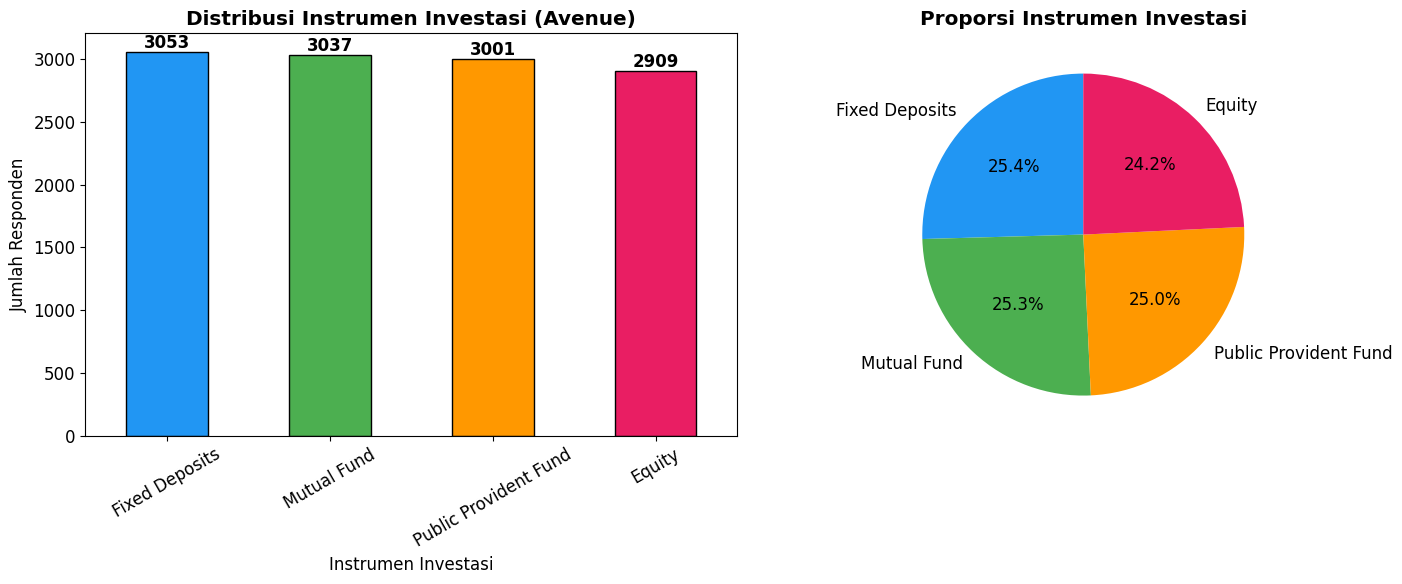

✅ Chart disimpan ke docs/


In [35]:
# ================================================
# CELL 5 — DISTRIBUSI TARGET (AVENUE)
# ================================================

print("DISTRIBUSI LABEL TARGET (AVENUE)")
print(df['Avenue'].value_counts())
print("\nPersentase:")
print(df['Avenue'].value_counts(normalize=True).mul(100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Bar Chart
df['Avenue'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63'],
    edgecolor='black'
)
axes[0].set_title('Distribusi Instrumen Investasi (Avenue)', 
                   fontweight='bold')
axes[0].set_xlabel('Instrumen Investasi')
axes[0].set_ylabel('Jumlah Responden')
axes[0].tick_params(axis='x', rotation=30)

# Tambah label angka di tiap bar
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontweight='bold'
    )

# Pie Chart
df['Avenue'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['#2196F3', '#4CAF50', '#FF9800', '#E91E63'],
    startangle=90
)
axes[1].set_title('Proporsi Instrumen Investasi', 
                   fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../docs/01_distribusi_target.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart disimpan ke docs/")

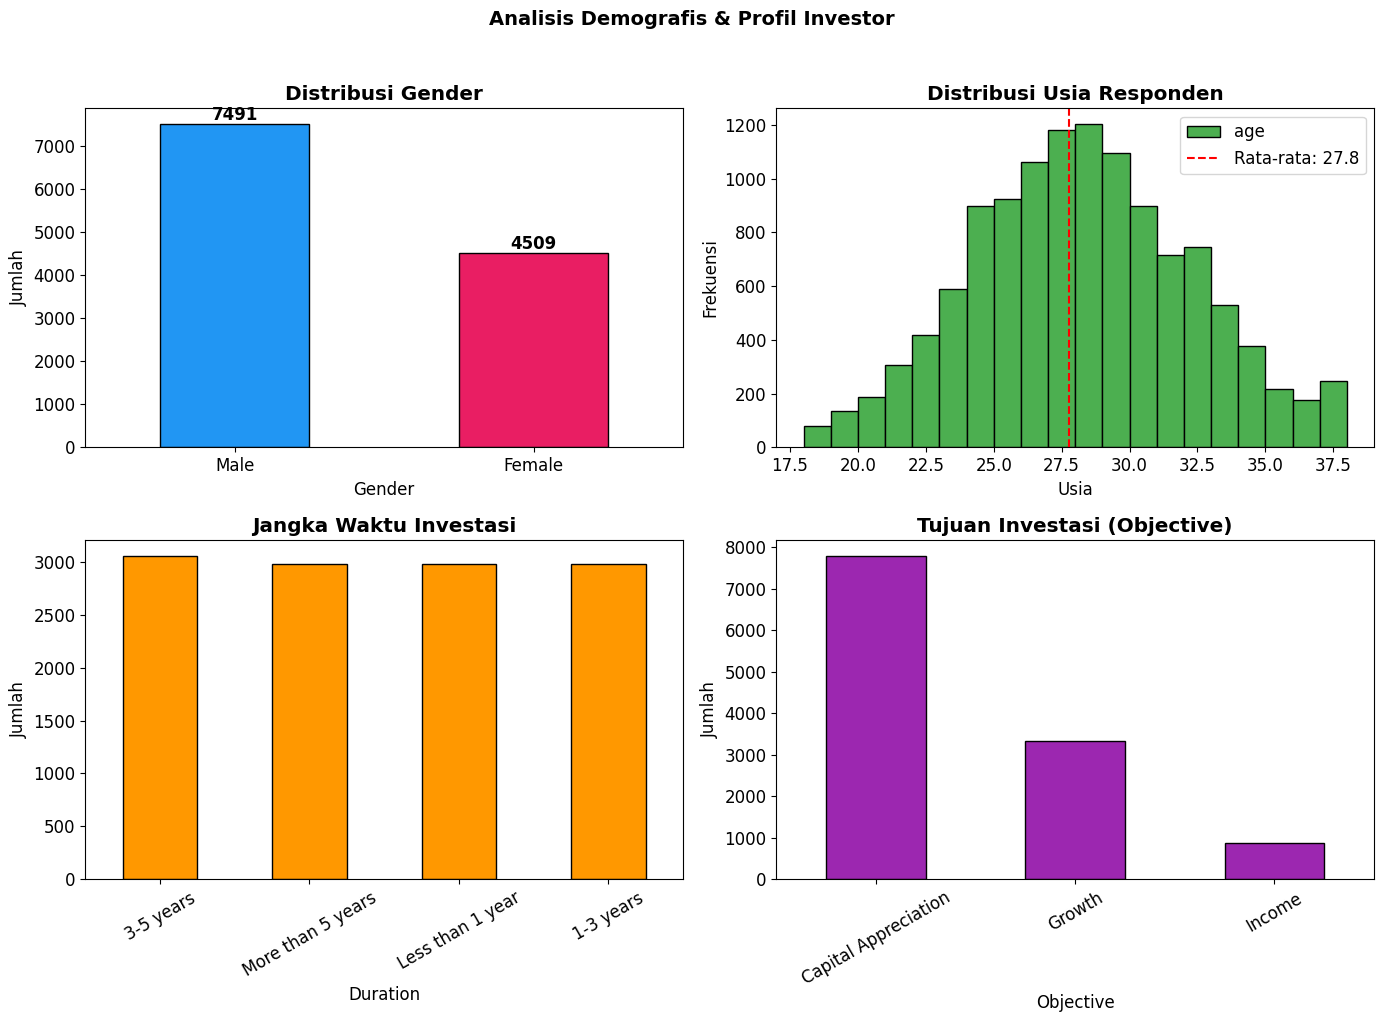

In [36]:
# ================================================
# CELL 6 — ANALISIS DEMOGRAFIS
# ================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi Gender
df['gender'].value_counts().plot(
    kind='bar', ax=axes[0,0],
    color=['#2196F3', '#E91E63'],
    edgecolor='black'
)
axes[0,0].set_title('Distribusi Gender', fontweight='bold')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Jumlah')
axes[0,0].tick_params(axis='x', rotation=0)
for p in axes[0,0].patches:
    axes[0,0].annotate(str(int(p.get_height())),
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontweight='bold')

# 2. Distribusi Usia
df['age'].plot(
    kind='hist', ax=axes[0,1],
    bins=20, color='#4CAF50',
    edgecolor='black'
)
axes[0,1].set_title('Distribusi Usia Responden', fontweight='bold')
axes[0,1].set_xlabel('Usia')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].axvline(df['age'].mean(), color='red',
                   linestyle='--', label=f"Rata-rata: {df['age'].mean():.1f}")
axes[0,1].legend()

# 3. Distribusi Duration
df['Duration'].value_counts().plot(
    kind='bar', ax=axes[1,0],
    color='#FF9800', edgecolor='black'
)
axes[1,0].set_title('Jangka Waktu Investasi', fontweight='bold')
axes[1,0].set_xlabel('Duration')
axes[1,0].set_ylabel('Jumlah')
axes[1,0].tick_params(axis='x', rotation=30)

# 4. Distribusi Objective
df['Objective'].value_counts().plot(
    kind='bar', ax=axes[1,1],
    color='#9C27B0', edgecolor='black'
)
axes[1,1].set_title('Tujuan Investasi (Objective)', fontweight='bold')
axes[1,1].set_xlabel('Objective')
axes[1,1].set_ylabel('Jumlah')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Analisis Demografis & Profil Investor',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/02_analisis_demografis.png',
            dpi=150, bbox_inches='tight')
plt.show()

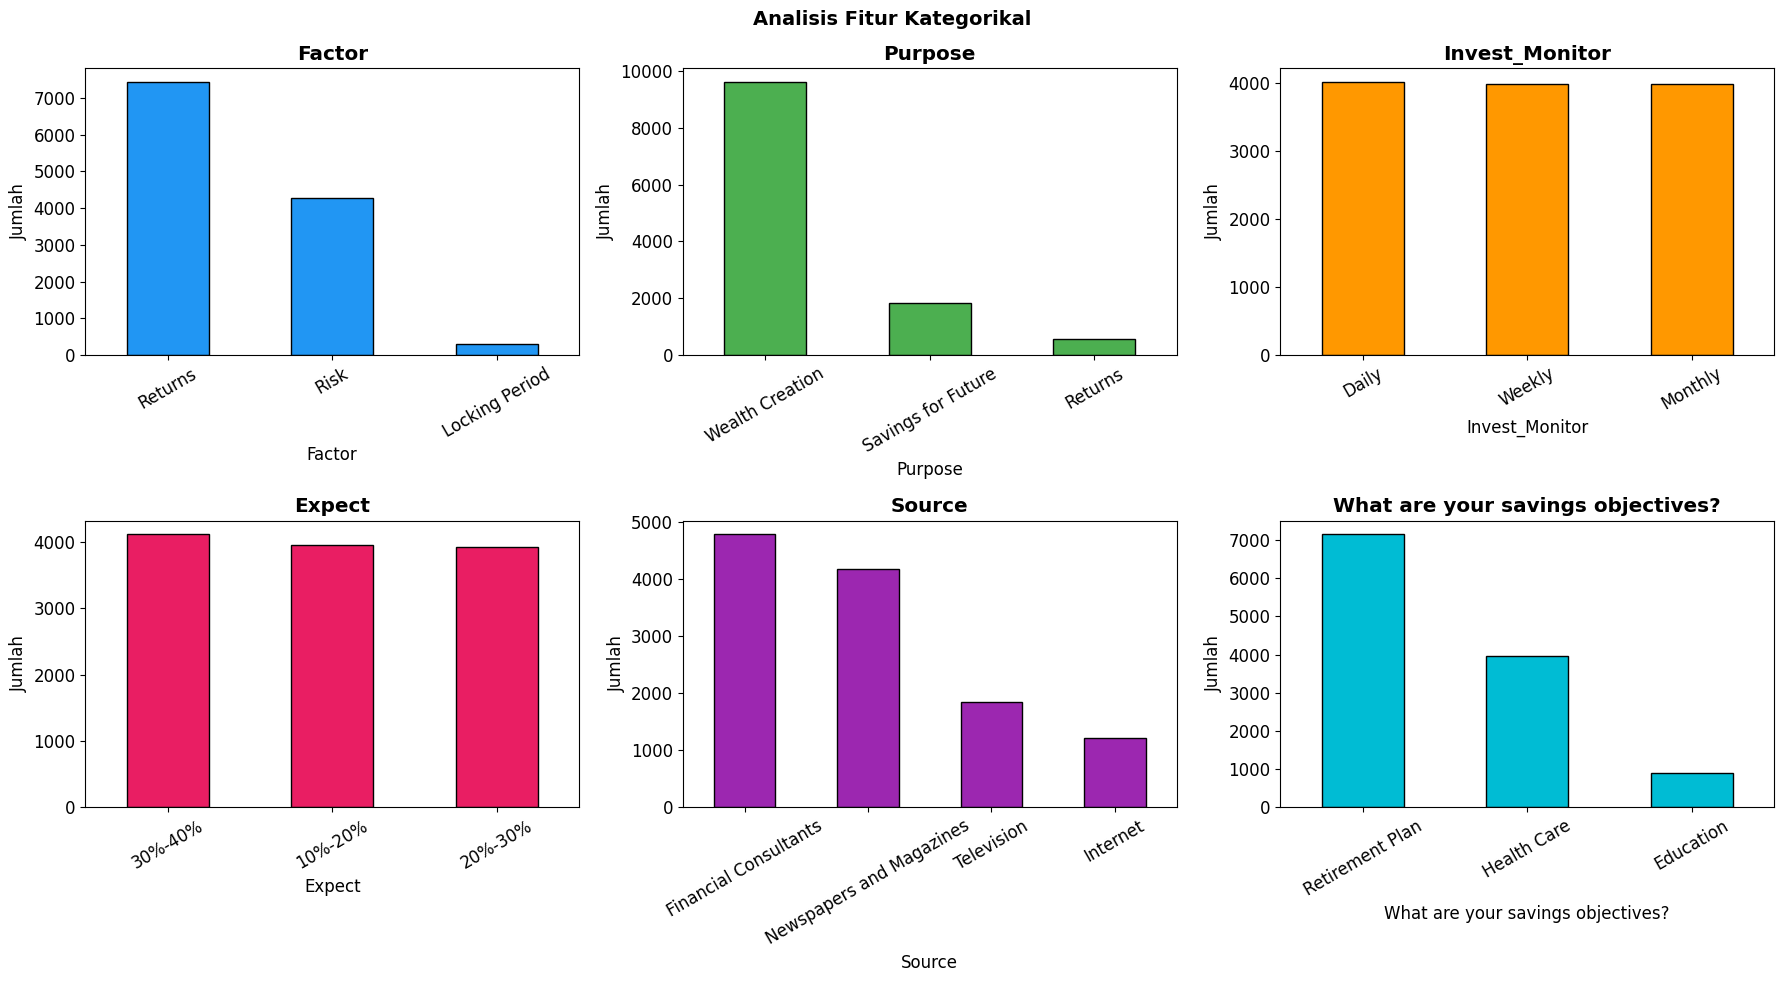

In [37]:
# ================================================
# CELL 7 — ANALISIS FITUR KATEGORIKAL LAINNYA
# ================================================

fitur_kategorik = ['Factor', 'Purpose', 'Invest_Monitor',
                   'Expect', 'Source',
                   'What are your savings objectives?']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800',
          '#E91E63', '#9C27B0', '#00BCD4']

for i, col in enumerate(fitur_kategorik):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        color=colors[i],
        edgecolor='black'
    )
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Analisis Fitur Kategorikal',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/03_fitur_kategorikal.png',
            dpi=150, bbox_inches='tight')
plt.show()

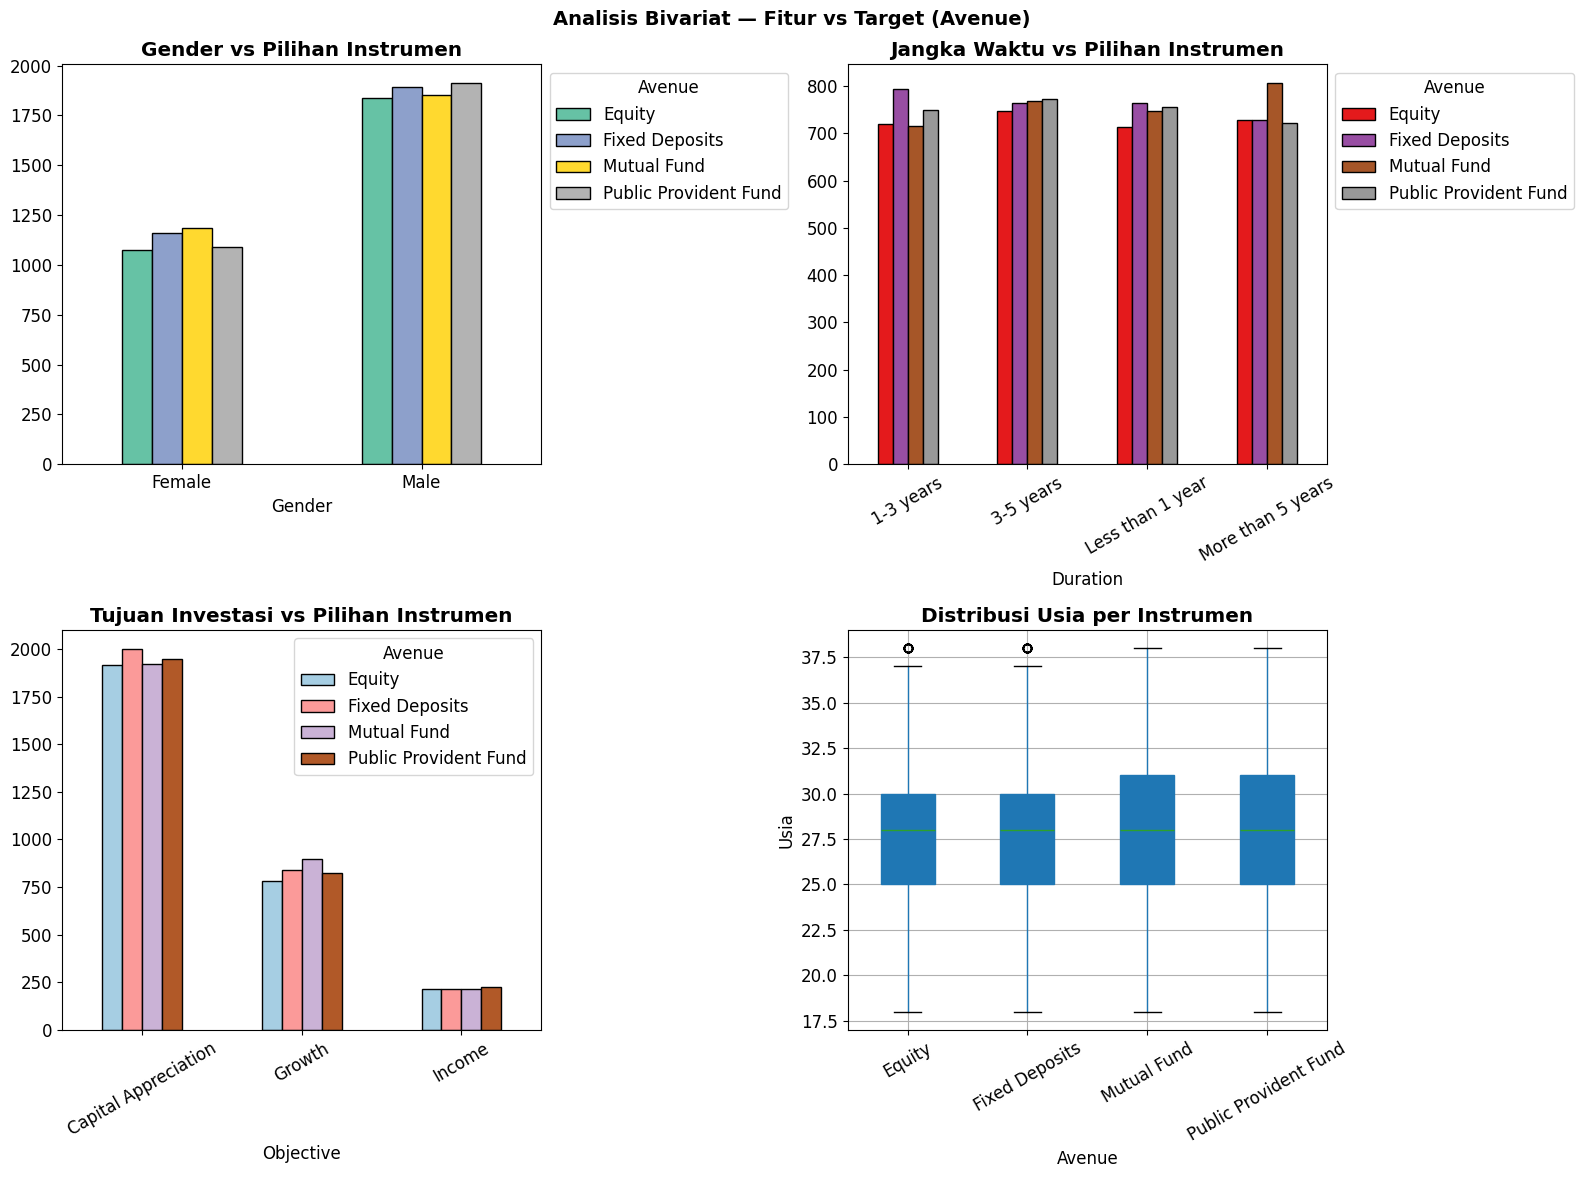

In [38]:
# ================================================
# CELL 8 — ANALISIS BIVARIAT (FITUR VS TARGET)
# ================================================
# Melihat hubungan setiap fitur dengan Avenue (target)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gender vs Avenue
pd.crosstab(df['gender'], df['Avenue']).plot(
    kind='bar', ax=axes[0,0],
    colormap='Set2', edgecolor='black'
)
axes[0,0].set_title('Gender vs Pilihan Instrumen',
                     fontweight='bold')
axes[0,0].set_xlabel('Gender')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].legend(title='Avenue', bbox_to_anchor=(1, 1))

# 2. Duration vs Avenue
pd.crosstab(df['Duration'], df['Avenue']).plot(
    kind='bar', ax=axes[0,1],
    colormap='Set1', edgecolor='black'
)
axes[0,1].set_title('Jangka Waktu vs Pilihan Instrumen',
                     fontweight='bold')
axes[0,1].set_xlabel('Duration')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(title='Avenue', bbox_to_anchor=(1, 1))

# 3. Objective vs Avenue
pd.crosstab(df['Objective'], df['Avenue']).plot(
    kind='bar', ax=axes[1,0],
    colormap='Paired', edgecolor='black'
)
axes[1,0].set_title('Tujuan Investasi vs Pilihan Instrumen',
                     fontweight='bold')
axes[1,0].set_xlabel('Objective')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend(title='Avenue', bbox_to_anchor=(1, 1))

# 4. Usia vs Avenue (boxplot)
df.boxplot(column='age', by='Avenue',
           ax=axes[1,1], patch_artist=True)
axes[1,1].set_title('Distribusi Usia per Instrumen',
                     fontweight='bold')
axes[1,1].set_xlabel('Avenue')
axes[1,1].set_ylabel('Usia')
plt.sca(axes[1,1])
plt.xticks(rotation=30)

plt.suptitle('Analisis Bivariat — Fitur vs Target (Avenue)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/04_analisis_bivariat.png',
            dpi=150, bbox_inches='tight')
plt.show()

Kolom numerik: ['age', 'Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold']


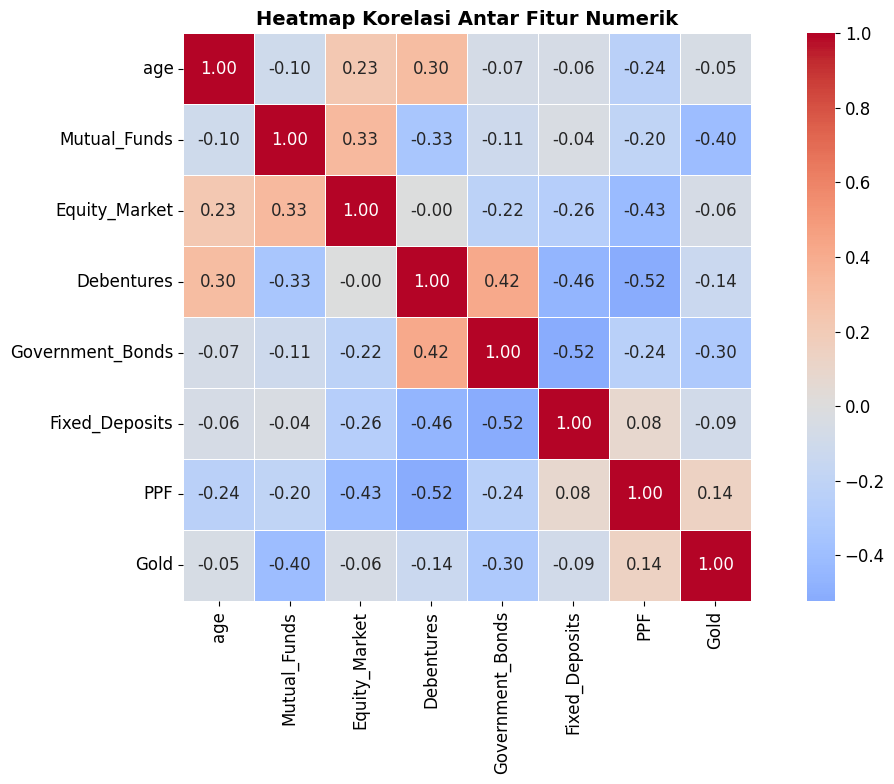

In [39]:
# ================================================
# CELL 9 — HEATMAP KORELASI
# ================================================
# Hanya untuk kolom numerik

kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
print("Kolom numerik:", kolom_numerik)

plt.figure(figsize=(12, 8))
korelasi = df[kolom_numerik].corr()

sns.heatmap(
    korelasi,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Heatmap Korelasi Antar Fitur Numerik',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/05_heatmap_korelasi.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ================================================
# CELL 10 — RINGKASAN TEMUAN EDA
# ================================================

print("=" * 60)
print("📋 RINGKASAN TEMUAN EDA")
print("=" * 60)

print(f"""
📊 INFORMASI DATASET:
   • Total data      : {df.shape[0]:,} baris
   • Total fitur     : {df.shape[1]} kolom
   • Missing values  : {df.isnull().sum().sum()}
   • Data duplikat   : {df.duplicated().sum()}

🎯 TARGET (Avenue):
   • Jumlah kelas    : {df['Avenue'].nunique()}
   • Kelas terbanyak : {df['Avenue'].value_counts().index[0]}
                       ({df['Avenue'].value_counts().iloc[0]:,} data)
   • Kelas tersedikit: {df['Avenue'].value_counts().index[-1]}
                       ({df['Avenue'].value_counts().iloc[-1]:,} data)
   • Status balance  : {'✅ Seimbang' if df['Avenue'].value_counts().std() < 200 else '⚠️ Tidak seimbang'}

👥 DEMOGRAFIS:
   • Rentang usia    : {df['age'].min()} - {df['age'].max()} tahun
   • Rata-rata usia  : {df['age'].mean():.1f} tahun
   • Dominan gender  : {df['gender'].value_counts().index[0]}
                       ({df['gender'].value_counts().iloc[0]:,} orang)

📌 REKOMENDASI PREPROCESSING:
   1. Encoding kolom kategorikal
      (Label Encoding / One-Hot Encoding)
   2. Normalisasi kolom numerik (age, skor instrumen)
   3. Split data: 80% train, 20% test
   4. Dataset sudah bersih, tidak perlu
      handling missing values
""")

print("=" * 60)
print("✅ EDA SELESAI! Siap ke tahap Data Preparation")
print("=" * 60)

📋 RINGKASAN TEMUAN EDA

📊 INFORMASI DATASET:
   • Total data      : 12,000 baris
   • Total fitur     : 24 kolom
   • Missing values  : 0
   • Data duplikat   : 1611

🎯 TARGET (Avenue):
   • Jumlah kelas    : 4
   • Kelas terbanyak : Fixed Deposits
                       (3,053 data)
   • Kelas tersedikit: Equity
                       (2,909 data)
   • Status balance  : ✅ Seimbang

👥 DEMOGRAFIS:
   • Rentang usia    : 18 - 38 tahun
   • Rata-rata usia  : 27.8 tahun
   • Dominan gender  : Male
                       (7,491 orang)

📌 REKOMENDASI PREPROCESSING:
   1. Encoding kolom kategorikal
      (Label Encoding / One-Hot Encoding)
   2. Normalisasi kolom numerik (age, skor instrumen)
   3. Split data: 80% train, 20% test
   4. Dataset sudah bersih, tidak perlu
      handling missing values

✅ EDA SELESAI! Siap ke tahap Data Preparation
